##### Feladat (Példatár 1.24)

Egy befogott tartó terhelése az ábrán látható megoszló csavaró erőrendszer. A tartó anyagára megengedett csúsztatófeszültség $\tau_\mathrm{meg} = 150 ~\mathrm{MPa}$, a csúsztató rugalmassági modulusz értéke $70 ~ \mathrm{GPa}$.

Méretezzük a tartót: 

a) Tömör kör keresztmetszetből!

b) Körgyűrű keresztmetszetből, ahol a belső átmérő 0,6x-osa a külső átmérőnek!

Ábrázoljuk a keresztmetszetek  elcsavarodási szögét a befogáshoz képest a tartó hossza mentén a tömör keresztmetszet választásakor!

<img src="img/01.jpg" alt="Feladat" width=350px>

##### Csomagok importálása

In [1]:
import numpy as np # Numerikus számítások
import matplotlib.pyplot as plt # Ábrázolás
plt.rcParams['mathtext.fontset'] = 'cm' # Betűtípus az ábrákon
plt.rcParams['font.family'] = 'serif' # Betűtípus az ábrákon
plt.rcParams['font.serif'] = ['cmr10'] # Betűtípus az ábrákon
plt.rcParams['axes.formatter.use_mathtext'] = True # Betűtípus az ábrákon
plt.rcParams['axes.unicode_minus'] = False # Betűtípus az ábrákon
from IPython.display import display, Math, Latex # Szép kimenet Jupyter notebookban
import sympy as sp # Szimbólikus számítások
from sympy import latex # Szép kimenet Jupyter notebookban
sp.init_printing() # Szép kimenet Jupyter notebookban

##### Adatok

In [2]:
Mt1_data = 500 # Nm/m
Mt2_data = 1000 # Nm/m
L_data = 0.5 # m
tau_meg_data = 150 # MPa
G_data = 70 # GPa

# Átváltás N, mm, MPa rendszerbe
L_data = L_data * 10**3 # mm
G_data = G_data * 10**3 # MPa

In [3]:
Mt1, Mt2, L, x, d_1, d_2, tau_meg, G = sp.symbols('M_t1, M_t2, L, x, d_1, d_2, \tau_meg, G')

In [4]:
data = [(Mt1, Mt1_data),
        (Mt2, Mt2_data),
        (L, L_data),
        (tau_meg, tau_meg_data),
        (G, G_data),]

#### a) Méretezés tömör keresztmetszetből

##### Csavaró igénybevétel

In [5]:
# 2. szakasz (jobb oldalról felírva)
Mt_II = Mt2*(2*L - x)
display(Math(rf'M_{{t,II}} = {latex(Mt_II)}'))

# 1. szakasz (jobb oldalról felírva)
Mt_I =  Mt2*L - Mt1*(L - x)
display(Math(rf'M_{{t,I}} = {latex(Mt_I)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
# Numerikus függvények
Mt_I_num = sp.lambdify(x, Mt_I.subs(data), modules='numpy')
Mt_II_num = sp.lambdify(x, Mt_II.subs(data), modules='numpy')

# x értékek
x_I_vals = np.linspace(0, L.subs(data), dtype=float)
x_II_vals = np.linspace(L.subs(data), (2*L).subs(data), dtype=float)

# y értékek
Mt_I_vals = Mt_I_num(x_I_vals)
Mt_II_vals = Mt_II_num(x_II_vals)

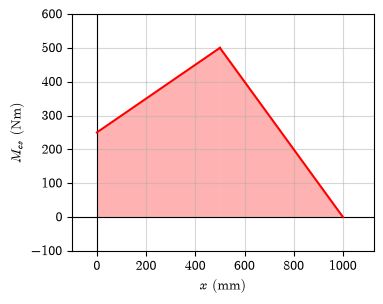

In [7]:
# Ábrázolás
plt.figure(figsize=(10/2.54, 8/2.54))
plt.plot(x_I_vals, Mt_I_vals * 1e-3, color='red', zorder=5)
plt.fill_between(x_I_vals, Mt_I_vals * 1e-3, 0, color='red', alpha=0.3, linewidth=0)
plt.plot(x_II_vals, Mt_II_vals * 1e-3, color='red', zorder=5)
plt.fill_between(x_II_vals, Mt_II_vals * 1e-3, 0, color='red', alpha=0.3, linewidth=0)
plt.axvline(0, color='black', linewidth=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel(r'$x ~ \mathrm{(mm)}$')
plt.ylabel(r'$M_{cs} ~ \mathrm{(Nm)}$')
plt.grid(True, alpha=0.5)
plt.xlim(-100, 2.25*float(L.subs(data)))
plt.ylim(-100, 600)
plt.tight_layout()
plt.savefig('csavaronyomateki_igenybevetel.pdf')
plt.show()

##### Maximnális csúsztatófeszültség

In [8]:
# Maximális csavarónyomaték
Mt_max = np.max(np.concatenate((Mt_I_vals, Mt_II_vals)))
display(Math(rf'M_{{t,max}} = {latex(Mt_max)} ~\mathrm{{Nmm}}'))

<IPython.core.display.Math object>

##### Méretezés

In [9]:
# Poláris keresztmetszeti tényező
K_p = d_1**3*sp.pi/16

# Ébredő feszültség
tau_max = Mt_max / K_p

# Határhelyzet
eq = (tau_max - tau_meg).subs(data)
sol = sp.solve(eq, d_1)
d_1sol = sol[0]
display(Math(rf'd_1 = {latex(round(d_1sol, 3))} ~\mathrm{{mm}}'))

<IPython.core.display.Math object>

#### b) Méretezés tkörgyűrű keresztmetszetből

##### Méretezés

In [10]:
# Poláris keresztmetszeti tényező
I_p = (d_2**4 - (0.6*d_2)**4)*sp.pi/32

K_p = I_p / (d_2/2)

# Ébredő feszültség
tau_max = Mt_max / K_p

# Határhelyzet
eq = (tau_max - tau_meg).subs(data)
sol = sp.solve(eq, d_2)
d_2sol = sol[0]
display(Math(rf'd_2 = {latex(round(d_2sol, 3))} ~\mathrm{{mm}}'))

<IPython.core.display.Math object>

#### Keresztmetszetek összehasonlítása

In [11]:
# Tömör keresztmetszet
A_a = d_1sol**2*sp.pi/4
display(Math(rf'A_a = {latex(round(A_a, 3))} ~\mathrm{{mm^2}}'))

# Körgyűrű keresztmetszet
A_b = (d_2sol**2 - (0.6*d_2sol)**2)*sp.pi/4
display(Math(rf'A_b = {latex(round(A_b, 3))} ~\mathrm{{mm^2}}'))

# A keresztmetszetek aránya
ratio = 1 - (A_b / A_a)
display(Latex('Ezek aránya:'))
display(Math(rf'1 - \frac{{A_b}}{{A_b}} = {latex(round(ratio*100, 3))}\%'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

#### $C$ keresztmetszet elcsavarodása ha a tömör megoldást használjuk

In [12]:
# Poláris másodrendű nyomaték
I_p = d_1sol**4*sp.pi/32
display(Math(rf'I_p = {latex(round(I_p, 3))} ~ \mathrm{{mm^4}}'))

# Csúsztató rugalmassági modulusz
display(Math(rf'G = {latex(round(G.subs(data), 3))} ~ \mathrm{{MPa}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [13]:
# Keresztmetszet elcsavarodása

# 1. szakasz
phi_1 = 1/(I_p*G) * sp.integrate(Mt_I, (x, 0, x)) # integrálás
phi_1 = phi_1 * 180 / sp.pi # átváltás radiánból fokba
display(Math(rf'\varphi_1(x) = {latex(phi_1.subs(data).evalf(5))} ~[^\circ], ~ ha ~ x~[\mathrm{{mm}}]'))

# 2. szakasz
phi_2 = 1/(I_p*G) * sp.integrate(Mt_II, (x, L_data, x)) # integrálás
phi_2 = phi_2 * 180 / sp.pi # átváltás radiánból fokba
phi_2 = phi_1.subs(data).subs(x, L_data) + phi_2
display(Math(rf'\varphi_2(x) = {latex(phi_2.subs(data).evalf(5))} ~[^\circ], ~ ha ~ x~[\mathrm{{mm}}]'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [14]:
# C keresztmetszet elcsavarodása
phi_C = phi_1.subs(data).subs(x, L_data)
display(Math(rf'\varphi_C =  \varphi_1(x=L) = {latex(phi_C.evalf(4))}^\circ'))

# B keresztmetszet elcsavarodása
phi_B = phi_2.subs(data).subs(x, 2*L_data)
display(Math(rf'\varphi_B =  \varphi_1(x=2L) = {latex(phi_B.evalf(4))}^\circ'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

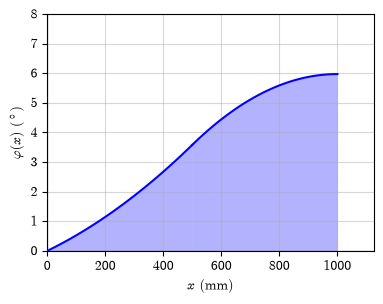

In [15]:
# Numerikus függvények
phi_1_num = sp.lambdify(x, phi_1.subs(data), modules='numpy')
phi_2_num = sp.lambdify(x, phi_2.subs(data), modules='numpy')

# x értékek
x_I_vals = np.linspace(0, L.subs(data), dtype=float)
x_II_vals = np.linspace(L.subs(data), (2*L).subs(data), dtype=float)

# y értékek
phi_1_vals = phi_1_num(x_I_vals)
phi_2_vals = phi_2_num(x_II_vals)

# Ábrázolás
plt.figure(figsize=(10/2.54, 8/2.54))
plt.plot(x_I_vals, phi_1_vals, color='blue', zorder=5)
plt.fill_between(x_I_vals, phi_1_vals, 0, color='blue', alpha=0.3, linewidth=0)
plt.plot(x_II_vals, phi_2_vals, color='blue', zorder=5)
plt.fill_between(x_II_vals, phi_2_vals, 0, color='blue', alpha=0.3, linewidth=0)
plt.axvline(0, color='black', linewidth=0.8)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel(r'$x ~ \mathrm{(mm)}$')
plt.ylabel(r'$\varphi (x) ~ \mathrm{(^\circ)}$')
plt.grid(True, alpha=0.5)
plt.xlim(0, 2.25*float(L.subs(data)))
plt.ylim(0, 8)
plt.tight_layout()
plt.savefig('szogelfordulas_fuggveny.pdf')
plt.show()